# Paired t-Test
<hr style="border:2.5px solid #126782">

<b>Reenylle Y. Jocson</b>
<br>Electronics Engineer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

**Dataset:** Pre and Post-Exercise Heart Rate Analysis

This dataset contains resting heart rate measurements of individuals
before and after exercise. Since the measurements come from the
same individuals, a paired t-test is used to determine whether
exercise significantly affects heart rate.

In [2]:
df = pd.read_csv("dataset/heart_rate_data.csv",
                 delimiter=",")
df

,Age,Sleep Hours,Exercise Frequency (Days/Week),Resting Heart Rate Before,Resting Heart Rate After,Max Heart Rate During Exercise
0,37,9.1,7,78,71,142
1,46,7.8,5,80,73,153
2,27,7.1,3,56,50,153
3,51,10.7,4,67,61,145
4,32,6.6,6,85,76,140
...,...,...,...,...,...,...
495,18,3.8,2,78,70,159
496,54,8.9,3,65,60,137
497,49,6.5,6,72,64,141
498,42,4.2,2,77,72,148


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             500 non-null    int64  
 1   Sleep Hours                     500 non-null    float64
 2   Exercise Frequency (Days/Week)  500 non-null    int64  
 3   Resting Heart Rate Before       500 non-null    int64  
 4   Resting Heart Rate After        500 non-null    int64  
 5   Max Heart Rate During Exercise  500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB


In [4]:
df = df.rename(columns={
    'Resting Heart Rate Before' : 'Before',
    'Resting Heart Rate After'  : 'After'})

df

,Age,Sleep Hours,Exercise Frequency (Days/Week),Before,After,Max Heart Rate During Exercise
0,37,9.1,7,78,71,142
1,46,7.8,5,80,73,153
2,27,7.1,3,56,50,153
3,51,10.7,4,67,61,145
4,32,6.6,6,85,76,140
...,...,...,...,...,...,...
495,18,3.8,2,78,70,159
496,54,8.9,3,65,60,137
497,49,6.5,6,72,64,141
498,42,4.2,2,77,72,148


### Summary of Statistics

In [5]:
df[['Before','After']].describe()

,Before,After
count,500.000000,500.000000
mean,71.640000,64.678000
std,8.373209,8.567913
min,45.000000,41.000000
25%,66.000000,59.000000
50%,72.000000,65.000000
75%,77.000000,70.000000
max,100.000000,93.000000


### Boxplot

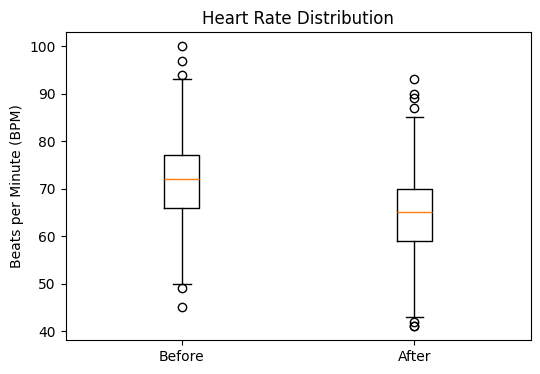

In [6]:
plt.figure(figsize=(6,4))

plt.boxplot(
    [df['Before'], df['After']],
    tick_labels=['Before','After']
)

plt.title("Heart Rate Distribution")
plt.ylabel("Beats per Minute (BPM)")

plt.show()

In [7]:
# Remove outliers using 3-sigma rule
z_before = stats.zscore(df['Before'])
z_after  = stats.zscore(df['After'])

df = df[(abs(z_before) < 3) & (abs(z_after) < 3)]
df.reset_index(drop=True, inplace=True)

df

,Age,Sleep Hours,Exercise Frequency (Days/Week),Before,After,Max Heart Rate During Exercise
0,37,9.1,7,78,71,142
1,46,7.8,5,80,73,153
2,27,7.1,3,56,50,153
3,51,10.7,4,67,61,145
4,32,6.6,6,85,76,140
...,...,...,...,...,...,...
492,18,3.8,2,78,70,159
493,54,8.9,3,65,60,137
494,49,6.5,6,72,64,141
495,42,4.2,2,77,72,148


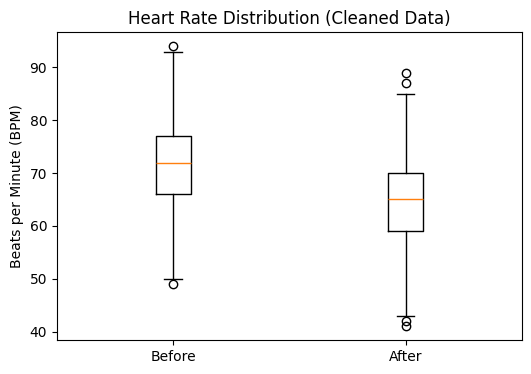

In [13]:
plt.figure(figsize=(6,4))

plt.boxplot(
    [df['Before'], df['After']],
    tick_labels=['Before','After']
)

plt.title("Heart Rate Distribution (Cleaned Data)")
plt.ylabel("Beats per Minute (BPM)")

plt.show()

### Normality Test

In [9]:
# Shapiro-Wilk normality test
print("Before:")
w_stat, p_value = stats.shapiro(df['Before'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

print("\nAfter:")
w_stat, p_value = stats.shapiro(df['After'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

Before:
w_stat: 0.9944
P-value: 0.0644
Normal data

After:
w_stat: 0.9957
P-value: 0.1919
Normal data


### F-Test

In [10]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_before = var_after
Ha: var_before != var_after
"""

var_before = df['Before'].var(ddof=1)
var_after  = df['After'].var(ddof=1)

# F-statistic
if var_before > var_after:
    f_stat = var_before / var_after
else:
    f_stat = var_after / var_before

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_before = df['Before'].count() - 1
dof_after  = df['After'].count() - 1

# p-value
p_value = 1 - stats.f.cdf(f_stat, dof_before, dof_after)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print('unequal variances')
else:
    print('equal variances')

f_stat = 1.0548
p_value = 0.2764
equal variances


### Paired t-Test

In [11]:
"""
Paired t-Test
--------------
Ho: mu_Before <= mu_After
Ha: mu_Before > mu_After
"""

t_stat, p_value = stats.ttest_rel(df['Before'], df['After'],
                                   alternative='greater')

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    print('Resting heart rate is significantly higher before exercise than after.')
else:
    print('There is no significant difference in resting heart rate before and after exercise.')

t_stat = 80.3131
p_value = 0.0000
Resting heart rate is significantly higher before exercise than after.


### Power of the Test

In [12]:
# Compute paired differences
diff = df['Before'] - df['After']

# Cohen's d for paired samples
cohens_d = diff.mean() / diff.std(ddof=1)

# Power analysis
analysis = TTestPower()
power = analysis.power(
    effect_size=cohens_d,
    nobs=len(diff),
    alpha=0.05
)
power_percent = power * 100

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Power of the test: {power_percent:.2f}%")

Cohen's d: 3.6025
Power of the test: 100.00%


## Conclusion

Using a paired t-test to evaluate whether resting heart rate is significantly
higher before exercise than after, the analysis yielded a t-statistic of
**80.3131** with a p-value of **< 0.0000**. At the 0.05 significance level,
the null hypothesis is **rejected**. This result indicates that exercise
significantly reduces resting heart rate in individuals.